# Faraday Rotation Impact on LuSEE Polarimetry

Analysis of Faraday rotation effects on LuSEE zoom-bin polarization measurements at 10, 30, and 50 MHz. Key question: can the 64 narrow zoom bins (~390 Hz each, 25 kHz total bandwidth) resolve Q/U rotation induced by the ionospheric Faraday effect?

In [1]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import healpy as hp
import h5py
from lunarsky import Time

import lusee_faraday as ld
from lusee_faraday.sky import load_rm, load_wmap

%matplotlib inline
plt.rcParams.update({
    "figure.dpi": 120,
    "font.size": 11,
    "axes.titlesize": 12,
    "axes.labelsize": 11,
})

# Paths
DATA = Path("../data")
RESULTS = Path("results")

# Colors (Paul Tol)
C_BLUE = "#4477AA"
C_RED = "#EE6677"
C_GREEN = "#228833"
C_YELLOW = "#CCBB44"
C_PURPLE = "#AA3377"
COLORS_3 = [C_BLUE, C_RED, C_GREEN]

In [2]:
# Load simulation results
sims = {}
for freq in [10, 30, 50]:
    sims[freq] = np.load(RESULTS / f"faraday_sim_{freq}mhz.npz")

# Quick summary
for freq, d in sims.items():
    ig = int(d["i_gal"])
    print(
        f"{freq} MHz: i_gal={ig}, "
        f"zoom shape={d['pQ_FR_zoom'].shape}, "
        f"wconv shape={d['pQ_FR_wconv'].shape}"
    )

10 MHz: i_gal=79, zoom shape=(100, 64), wconv shape=(1, 64)
30 MHz: i_gal=81, zoom shape=(100, 64), wconv shape=(1, 64)
50 MHz: i_gal=75, zoom shape=(100, 64), wconv shape=(1, 64)


## 1. FR Phase Behavior (Analytical)

The Faraday rotation angle is $\Delta\phi = 2\,\mathrm{RM}\,\lambda^2$. Across a bandwidth $\Delta\nu$, the phase change is:

$$\delta\phi \approx 4\,\mathrm{RM}\,\frac{c^2}{\nu^3}\,\Delta\nu$$

We compare this across the 25 kHz parent bin and the ~390 Hz zoom sub-bin.

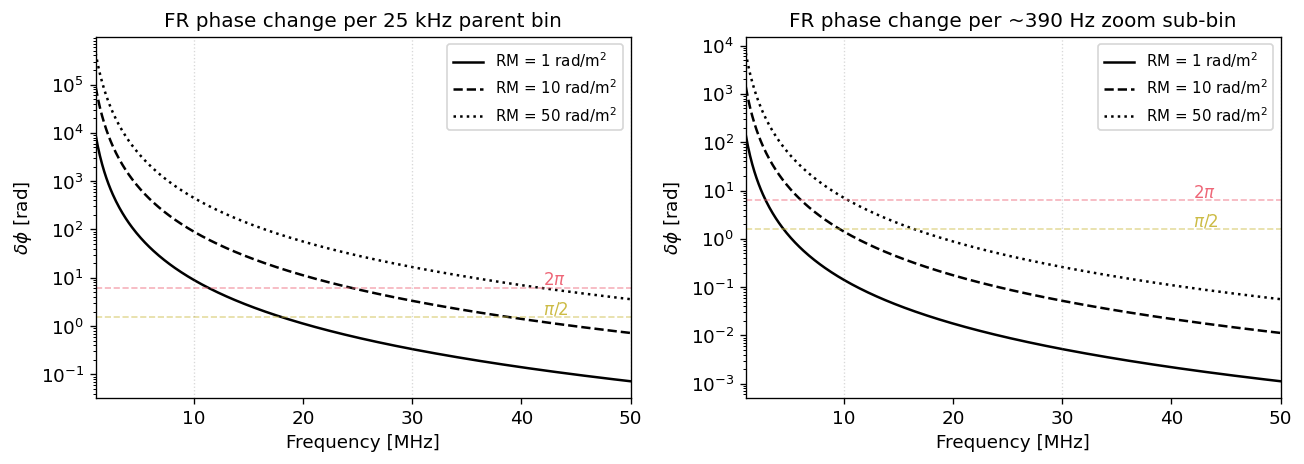

In [3]:
c = 3e8  # m/s
freqs_sweep = np.linspace(1, 50, 500)  # MHz
nu = freqs_sweep * 1e6  # Hz

BW_PARENT = 25e3  # 25 kHz parent bin
BW_ZOOM = BW_PARENT / 64  # ~390 Hz zoom sub-bin
RMs = [1, 10, 50]

fig, axes = plt.subplots(1, 2, figsize=(11, 4), sharey=False)

for ax, bw, label in zip(
    axes, [BW_PARENT, BW_ZOOM], ["25 kHz parent bin", "~390 Hz zoom sub-bin"]
):
    for rm, ls in zip(RMs, ["-", "--", ":"]):
        dphi = 4 * rm * c**2 / nu**3 * bw
        ax.semilogy(freqs_sweep, dphi, ls, color="k", lw=1.5,
                     label=f"RM = {rm} rad/m$^2$")
    ax.axhline(2 * np.pi, color=C_RED, ls="--", alpha=0.5, lw=1)
    ax.text(42, 2 * np.pi * 1.15, r"$2\pi$", color=C_RED, fontsize=10)
    ax.axhline(np.pi / 2, color=C_YELLOW, ls="--", alpha=0.5, lw=1)
    ax.text(42, np.pi / 2 * 1.15, r"$\pi/2$", color=C_YELLOW, fontsize=10)
    for fv in [10, 30, 50]:
        ax.axvline(fv, color="grey", ls=":", alpha=0.3, lw=0.8)
    ax.set_xlabel("Frequency [MHz]")
    ax.set_ylabel(r"$\delta\phi$ [rad]")
    ax.set_title(f"FR phase change per {label}")
    ax.legend(fontsize=9)
    ax.set_xlim(1, 50)

fig.tight_layout()
plt.show()

## 2. Rotation Measure Sky

The RM map from [Hutschenreuter et al. 2022](https://arxiv.org/abs/2102.01709), loaded at nside=128.

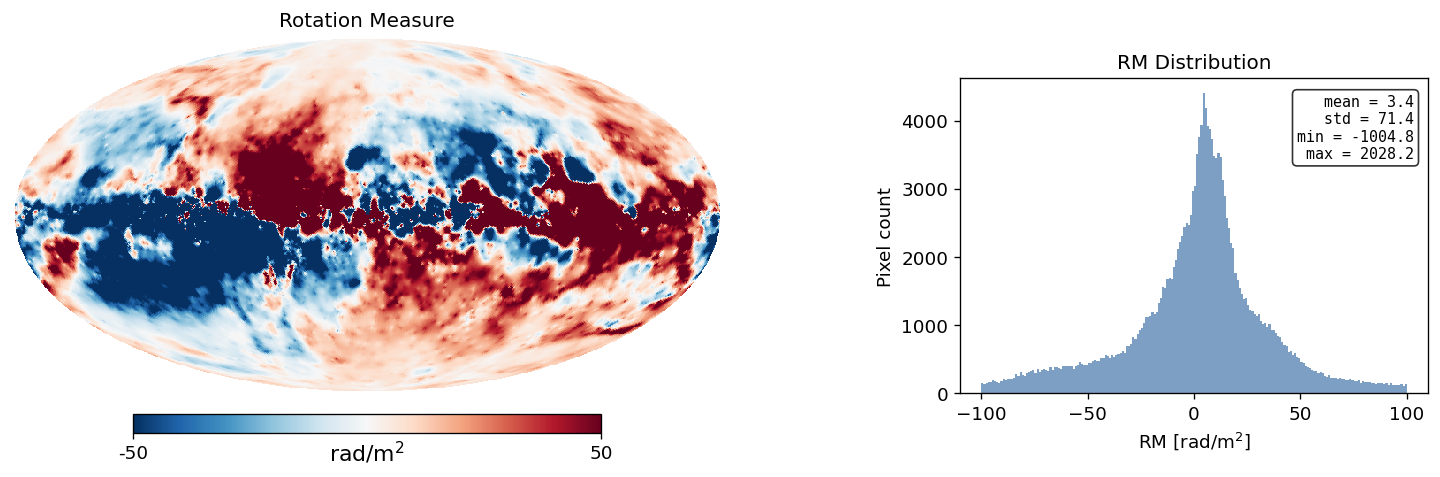

In [4]:
NSIDE = 128
rm = load_rm(DATA / "faraday2020v2.hdf5", nside=NSIDE)

fig = plt.figure(figsize=(13, 3.5))

# (a) Mollweide map
ax_mol = fig.add_axes([0.0, 0.0, 0.6, 1.0])
plt.sca(ax_mol)
hp.mollview(rm, title="Rotation Measure", unit="rad/m$^2$",
            hold=True, cmap="RdBu_r", min=-50, max=50)

# (b) Histogram
ax = fig.add_axes([0.68, 0.15, 0.30, 0.75])
rm_finite = rm[np.isfinite(rm)]
ax.hist(rm_finite, bins=200, range=(-100, 100), color=C_BLUE, alpha=0.7,
        edgecolor="none")
ax.set_xlabel("RM [rad/m$^2$]")
ax.set_ylabel("Pixel count")
ax.set_title("RM Distribution")
stats = (f"mean = {rm_finite.mean():.1f}\n"
         f"std = {rm_finite.std():.1f}\n"
         f"min = {rm_finite.min():.1f}\n"
         f"max = {rm_finite.max():.1f}")
ax.text(0.97, 0.95, stats, transform=ax.transAxes, fontsize=9,
        va="top", ha="right", family="monospace",
        bbox=dict(boxstyle="round", fc="white", alpha=0.8))

plt.show()

## 3. SHT Accuracy Analysis

The brute-force `Simulator` uses `healpy.map2alm` → `alm2map` roundtrips for coordinate rotation, which band-limits the map at $\ell_{\max} = 3\,N_{\mathrm{side}} - 1$. Faraday rotation creates sharp pixel-scale structure that leaks power beyond this limit. The `fast_sim` approach avoids this by rotating pixel-by-pixel.

In [5]:
# Load WMAP Q map and RM for SHT analysis
wmap = load_wmap(DATA / "wmap_band_iqumap_r9_9yr_K_v5.fits", nside=NSIDE)
Q_ref = wmap[1]  # Reference Q (no FR)

lmax = 3 * NSIDE - 1

def sht_roundtrip(m):
    """map -> alm -> map roundtrip (band-limits at lmax)."""
    alm = hp.map2alm(m, lmax=lmax)
    return hp.alm2map(alm, NSIDE, lmax=lmax)

def variance_loss(m):
    """Fraction of variance lost by SHT roundtrip."""
    m_rt = sht_roundtrip(m)
    return 1 - np.var(m_rt) / np.var(m)

# Apply FR at several frequencies
freq_test = [10, 20, 30, 40, 50]
Cls_FR = {}
for f in freq_test:
    lam2 = (c / (f * 1e6)) ** 2
    arg = 2 * rm * lam2
    Q_fr = Q_ref * np.cos(arg) - wmap[2] * np.sin(arg)
    Cls_FR[f] = hp.anafast(Q_fr, lmax=lmax)

Cl_ref = hp.anafast(Q_ref, lmax=lmax)
ell = np.arange(len(Cl_ref))

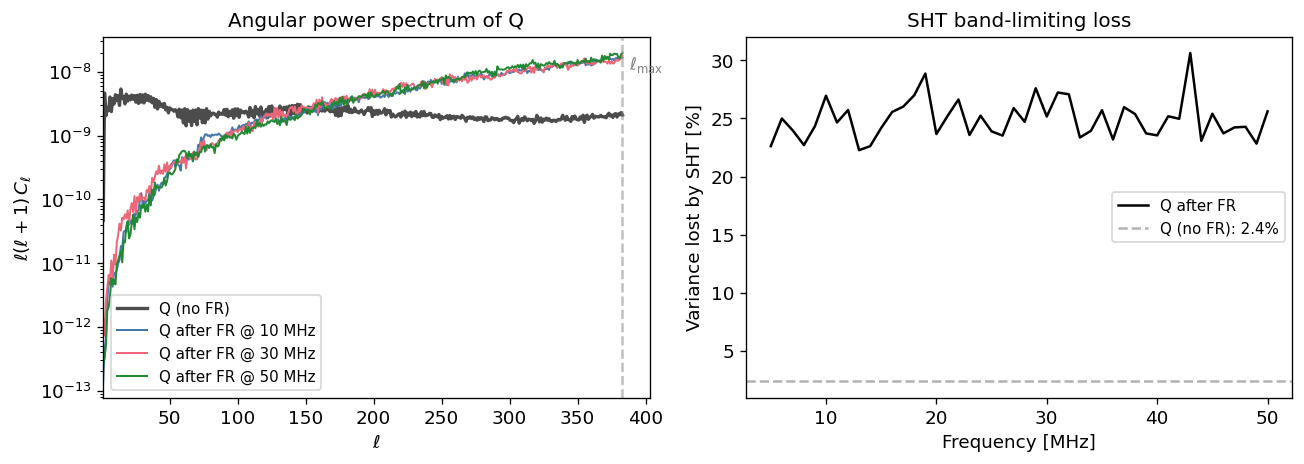

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# (a) Angular power spectra
ax = axes[0]
ax.semilogy(ell[1:], Cl_ref[1:] * ell[1:] * (ell[1:] + 1),
            "k-", lw=2, label="Q (no FR)", alpha=0.7)
for f, col in zip([10, 30, 50], COLORS_3):
    ax.semilogy(ell[1:], Cls_FR[f][1:] * ell[1:] * (ell[1:] + 1),
                color=col, lw=1.2, label=f"Q after FR @ {f} MHz")
ax.axvline(lmax, color="grey", ls="--", alpha=0.5)
ax.text(lmax + 5, ax.get_ylim()[1] * 0.3, r"$\ell_{\max}$",
        color="grey", fontsize=10)
ax.set_xlabel(r"$\ell$")
ax.set_ylabel(r"$\ell(\ell+1)\,C_\ell$")
ax.set_title("Angular power spectrum of Q")
ax.legend(fontsize=9)
ax.set_xlim(1, lmax + 20)

# (b) Variance loss vs frequency
ax = axes[1]
freq_fine = np.arange(5, 51, 1)
vloss = []
for f in freq_fine:
    lam2 = (c / (f * 1e6)) ** 2
    arg = 2 * rm * lam2
    Q_fr = Q_ref * np.cos(arg) - wmap[2] * np.sin(arg)
    vloss.append(variance_loss(Q_fr))
vloss_ref = variance_loss(Q_ref)

ax.plot(freq_fine, 100 * np.array(vloss), "k-", lw=1.5,
        label="Q after FR")
ax.axhline(100 * vloss_ref, color="grey", ls="--", alpha=0.6,
           label=f"Q (no FR): {100*vloss_ref:.1f}%")
ax.set_xlabel("Frequency [MHz]")
ax.set_ylabel("Variance lost by SHT [%]")
ax.set_title("SHT band-limiting loss")
ax.legend(fontsize=9)

fig.tight_layout()
plt.show()

## 4. Depolarization vs Frequency

Two complementary views of FR impact on polarized intensity:
- **Per-bin mean** $\langle P \rangle = \langle\sqrt{Q_i^2 + U_i^2}\rangle$ — average polarized intensity across zoom bins. This is insensitive to bandwidth depolarization and measures the true sky depolarization from RM dispersion within the beam.
- **Band-averaged** $P_\mathrm{avg} = \sqrt{\bar{Q}^2 + \bar{U}^2}$ where $\bar{Q}$ is the mean Q across bins. This includes bandwidth depolarization from coherent FR rotation across the 25 kHz band.

Note: the band-averaged ratio can exceed 1 when the no-FR beam average has low fractional polarization (partial cancellation of Q/U from different sky regions). FR rotates each pixel by a different angle (varying RM), breaking these cancellations.

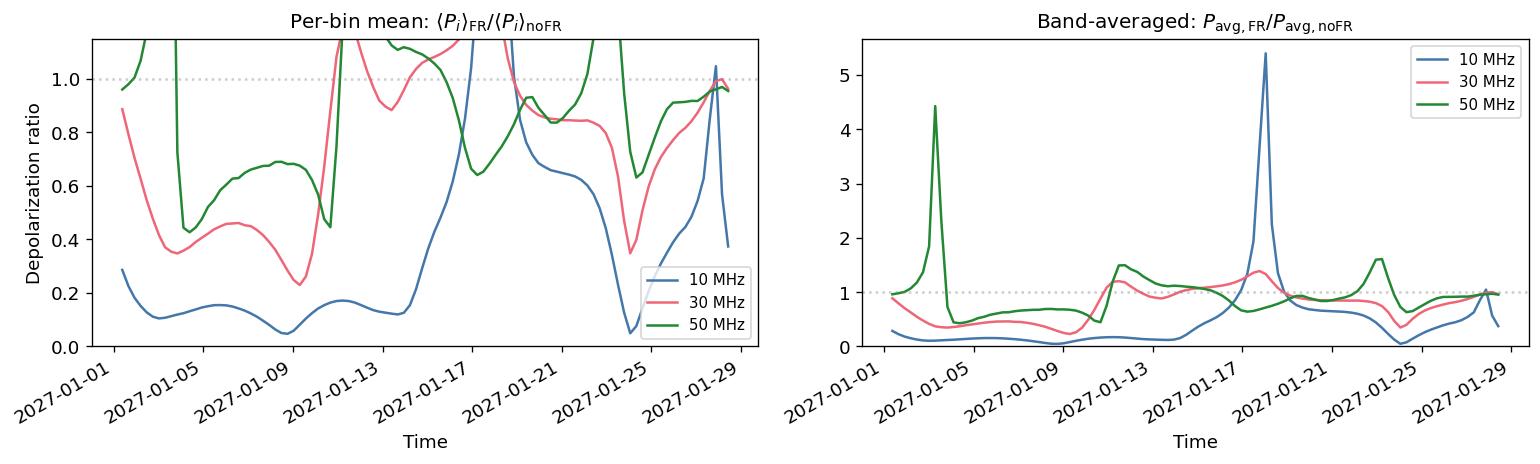

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4), sharex=True)

for freq, col in zip([10, 30, 50], COLORS_3):
    d = sims[freq]
    times = Time(d["times_jd"], format="jd").to_datetime()

    # (a) Per-bin mean P: <sqrt(Q_i^2 + U_i^2)>
    P_FR_perbin = np.sqrt(
        d["pQ_FR_zoom"] ** 2 + d["pU_FR_zoom"] ** 2
    ).mean(axis=1)
    P_noFR_perbin = np.sqrt(
        d["pQ_noFR_zoom"] ** 2 + d["pU_noFR_zoom"] ** 2
    ).mean(axis=1)
    ratio_perbin = np.where(
        P_noFR_perbin > 0, P_FR_perbin / P_noFR_perbin, np.nan
    )
    axes[0].plot(times, ratio_perbin, color=col, lw=1.5,
                 label=f"{freq} MHz")

    # (b) Band-averaged P: sqrt(<Q>^2 + <U>^2)
    P_FR_avg = np.sqrt(
        d["pQ_FR_zoom"].mean(axis=1) ** 2
        + d["pU_FR_zoom"].mean(axis=1) ** 2
    )
    P_noFR_avg = np.sqrt(
        d["pQ_noFR_zoom"].mean(axis=1) ** 2
        + d["pU_noFR_zoom"].mean(axis=1) ** 2
    )
    ratio_avg = np.where(
        P_noFR_avg > 0, P_FR_avg / P_noFR_avg, np.nan
    )
    axes[1].plot(times, ratio_avg, color=col, lw=1.5,
                 label=f"{freq} MHz")

for ax, title in zip(axes, [
    r"Per-bin mean: $\langle P_i \rangle_\mathrm{FR}"
    r" / \langle P_i \rangle_\mathrm{noFR}$",
    r"Band-averaged: $P_\mathrm{avg,FR}"
    r" / P_\mathrm{avg,noFR}$",
]):
    ax.set_xlabel("Time")
    ax.set_title(title)
    ax.legend(fontsize=9)
    ax.axhline(1.0, color="grey", ls=":", alpha=0.4)

axes[0].set_ylabel("Depolarization ratio")
axes[0].set_ylim(0, 1.15)
axes[1].set_ylim(0, None)
fig.autofmt_xdate()
fig.tight_layout()
plt.show()

## 5. Narrow-Bin Spectra (FR vs no-FR)

Galaxy-up time step: zoom-bin spectra showing FR-induced oscillations in Q and U, and depolarization in $P = \sqrt{Q^2 + U^2}$.

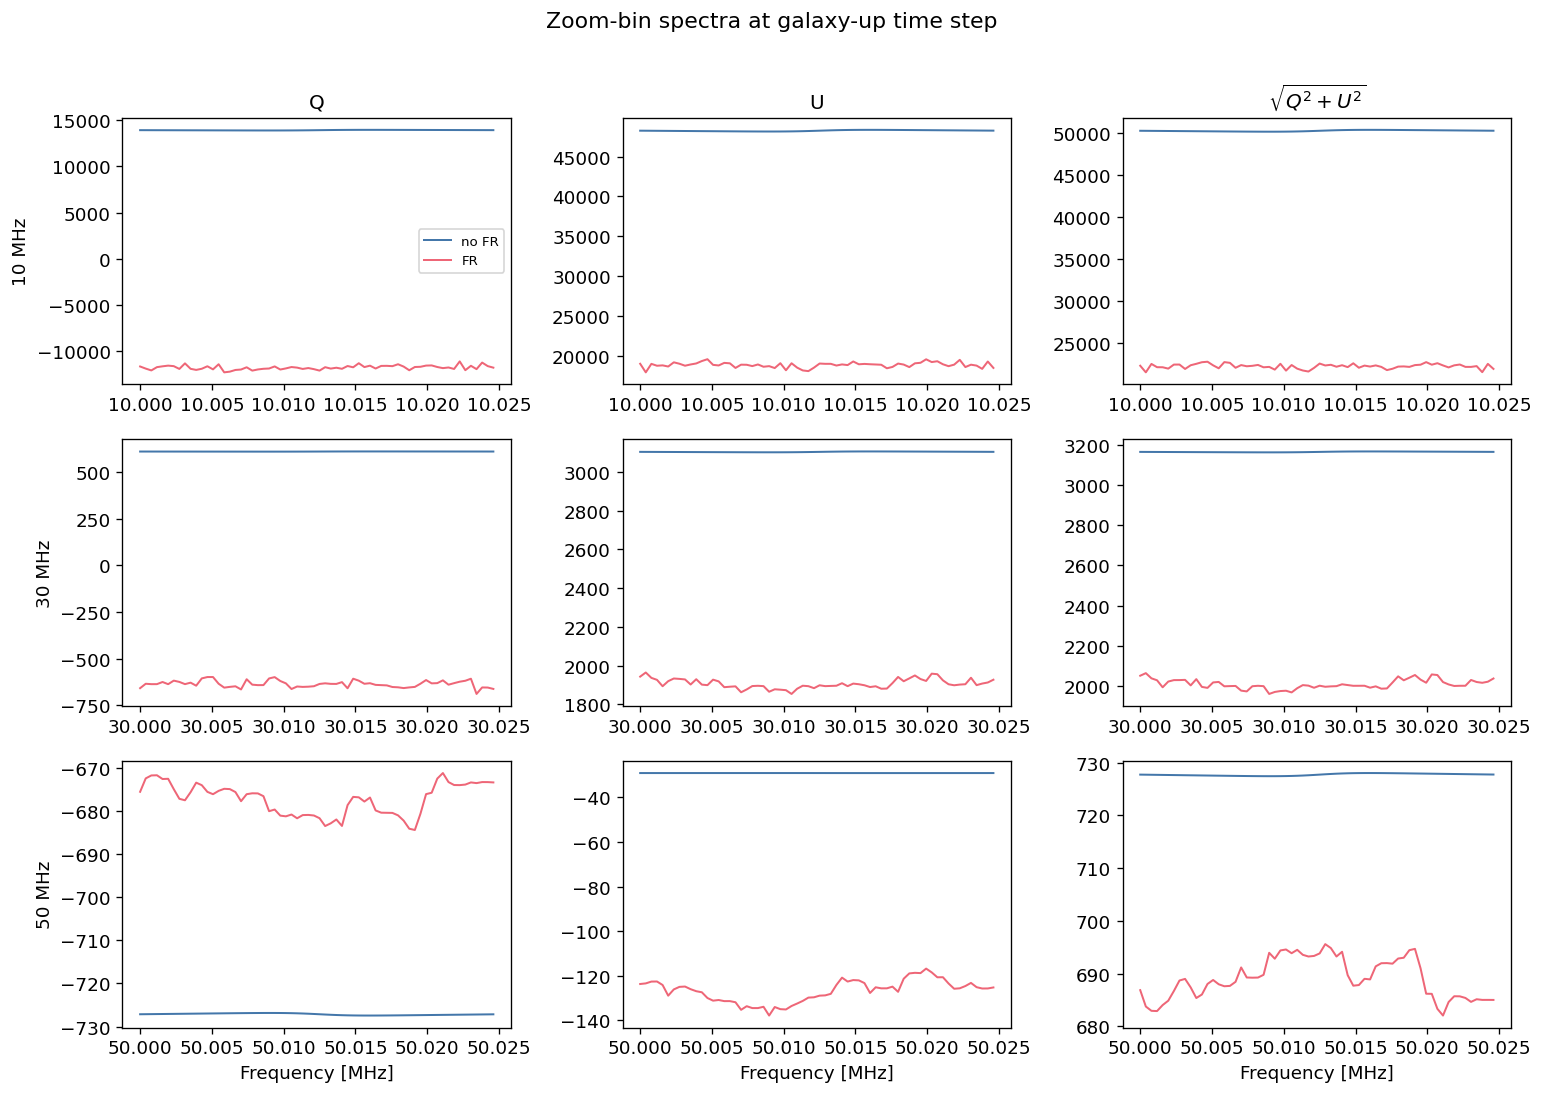

In [8]:
fig, axes = plt.subplots(3, 3, figsize=(13, 9))
center_freqs = [10, 30, 50]
stokes_labels = ["Q", "U", r"$\sqrt{Q^2+U^2}$"]

for row, freq in enumerate(center_freqs):
    d = sims[freq]
    ig = int(d["i_gal"])
    fz = d["freqs_zoom"]

    Q_fr = d["pQ_FR_zoom"][ig]
    U_fr = d["pU_FR_zoom"][ig]
    Q_no = d["pQ_noFR_zoom"][ig]
    U_no = d["pU_noFR_zoom"][ig]
    P_fr = np.sqrt(Q_fr**2 + U_fr**2)
    P_no = np.sqrt(Q_no**2 + U_no**2)

    data_pairs = [
        (Q_fr, Q_no), (U_fr, U_no), (P_fr, P_no)
    ]
    for col, ((y_fr, y_no), slbl) in enumerate(
        zip(data_pairs, stokes_labels)
    ):
        ax = axes[row, col]
        ax.plot(fz, y_no, color=C_BLUE, lw=1.2, label="no FR")
        ax.plot(fz, y_fr, color=C_RED, lw=1.2, label="FR")
        if row == 0:
            ax.set_title(slbl)
        if col == 0:
            ax.set_ylabel(f"{freq} MHz")
        if row == 2:
            ax.set_xlabel("Frequency [MHz]")
        if row == 0 and col == 0:
            ax.legend(fontsize=8)

fig.suptitle("Zoom-bin spectra at galaxy-up time step", y=1.01)
fig.tight_layout()
plt.show()

## 6. Q/U Phasor Rotation in Zoom Bins

Complex-plane plot of $Q + iU$ across the 64 zoom bins. If the bins resolve the FR rotation, the phasor traces a smooth arc; if under-resolved, it appears as a scrambled cloud.

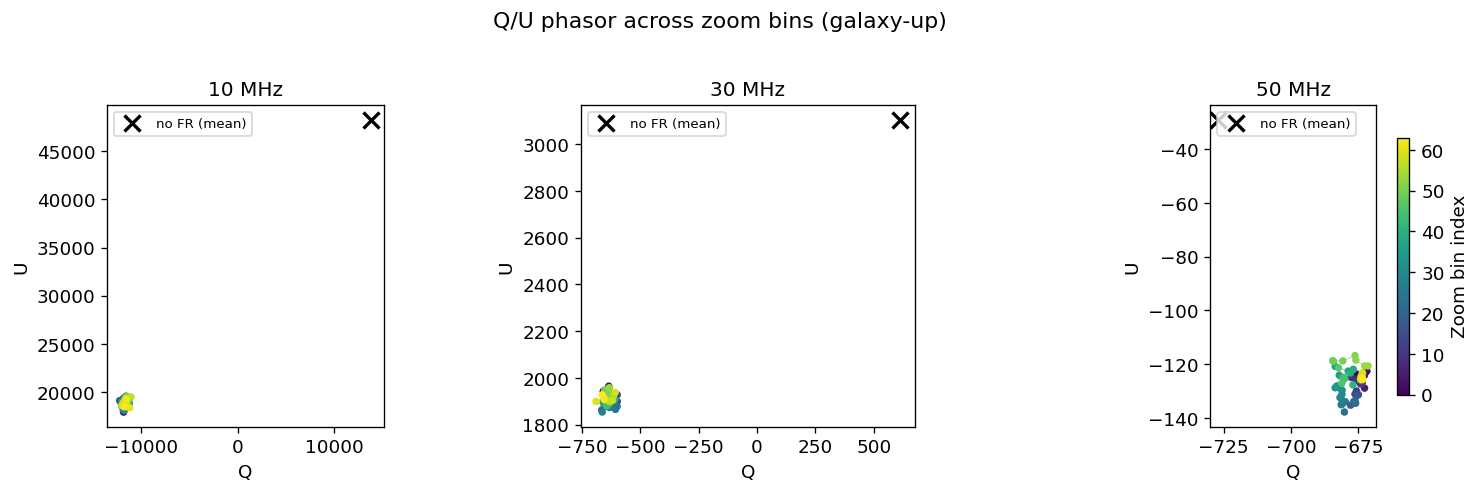

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4))

for ax, freq, col in zip(axes, [10, 30, 50], COLORS_3):
    d = sims[freq]
    ig = int(d["i_gal"])

    Q_fr = d["pQ_FR_zoom"][ig]
    U_fr = d["pU_FR_zoom"][ig]
    Q_no = d["pQ_noFR_zoom"][ig]
    U_no = d["pU_noFR_zoom"][ig]

    # FR: colored by bin index
    sc = ax.scatter(Q_fr, U_fr, c=np.arange(64), cmap="viridis",
                    s=20, zorder=3, edgecolors="none")
    ax.plot(Q_fr, U_fr, "-", color="grey", lw=0.5, alpha=0.5, zorder=2)

    # no-FR: single marker (mean, since bins are nearly identical)
    ax.plot(Q_no.mean(), U_no.mean(), "kx", ms=10, mew=2,
            label="no FR (mean)", zorder=4)

    ax.set_xlabel("Q")
    ax.set_ylabel("U")
    ax.set_title(f"{freq} MHz")
    ax.set_aspect("equal")
    ax.legend(fontsize=8, loc="upper left")

fig.colorbar(sc, ax=axes[-1], label="Zoom bin index", shrink=0.8)
fig.suptitle("Q/U phasor across zoom bins (galaxy-up)", y=1.02)
fig.tight_layout()
plt.show()

## 7. Delay-Space Analysis

FFT of Q and U zoom spectra to delay space. The expected FR delay is $\tau_\mathrm{FR} = 2\,\mathrm{RM}\,c^2 / (\pi\,\nu^3)$ for typical above-horizon RM.

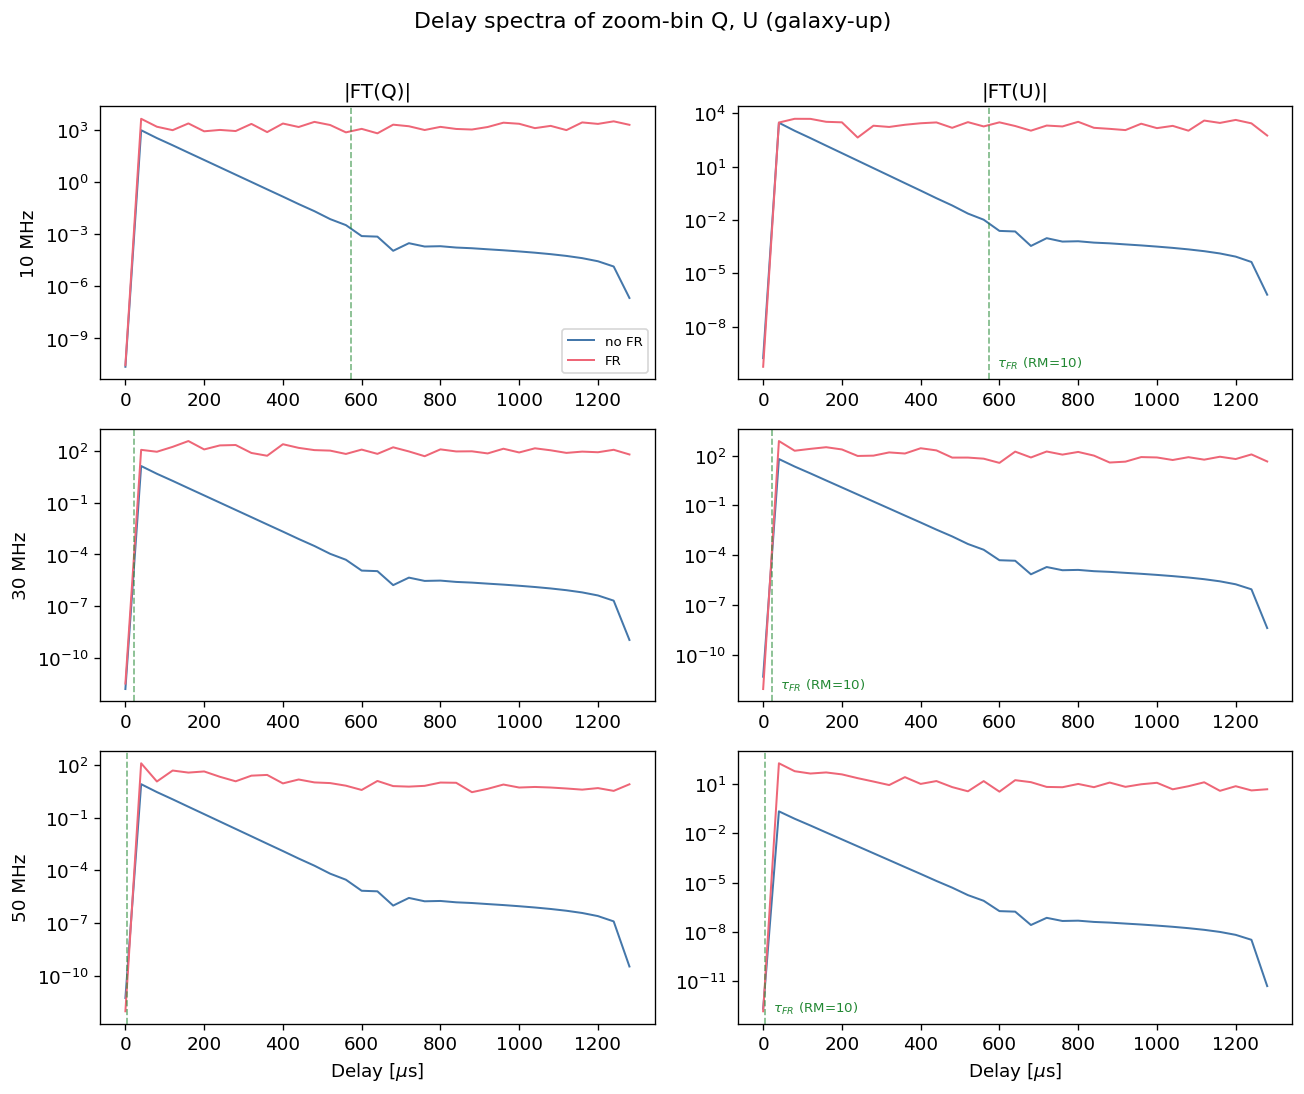

In [10]:
fig, axes = plt.subplots(3, 2, figsize=(11, 9))
stokes_keys = [("pQ", "Q"), ("pU", "U")]

# Typical RM for expected delay marker
RM_TYPICAL = 10  # rad/m^2

for row, freq in enumerate([10, 30, 50]):
    d = sims[freq]
    ig = int(d["i_gal"])
    fz = d["freqs_zoom"]
    df = (fz[-1] - fz[0]) / (len(fz) - 1)  # MHz

    # Expected FR delay
    nu_hz = freq * 1e6
    tau_fr = 2 * RM_TYPICAL * c**2 / (np.pi * nu_hz**3)
    tau_fr_us = tau_fr * 1e6  # microseconds

    for col, (key, slbl) in enumerate(stokes_keys):
        ax = axes[row, col]
        y_fr = d[f"{key}_FR_zoom"][ig]
        y_no = d[f"{key}_noFR_zoom"][ig]

        # FFT
        ft_fr = np.abs(np.fft.rfft(y_fr - y_fr.mean()))
        ft_no = np.abs(np.fft.rfft(y_no - y_no.mean()))
        tau = np.fft.rfftfreq(len(fz), d=df)  # 1/MHz = microseconds

        ax.semilogy(tau, ft_no, color=C_BLUE, lw=1.2, label="no FR")
        ax.semilogy(tau, ft_fr, color=C_RED, lw=1.2, label="FR")
        ax.axvline(tau_fr_us, color=C_GREEN, ls="--", alpha=0.6, lw=1)
        if col == 1:
            ax.text(
                tau_fr_us, ax.get_ylim()[0] * 3,
                f"  $\\tau_{{FR}}$ (RM={RM_TYPICAL})",
                color=C_GREEN, fontsize=8, va="bottom",
            )
        if row == 0:
            ax.set_title(f"|FT({slbl})|")
        if col == 0:
            ax.set_ylabel(f"{freq} MHz")
        if row == 2:
            ax.set_xlabel(r"Delay [$\mu$s]")
        if row == 0 and col == 0:
            ax.legend(fontsize=8)

fig.suptitle("Delay spectra of zoom-bin Q, U (galaxy-up)", y=1.01)
fig.tight_layout()
plt.show()

## 8. Wide-Bin Convolved Spectra

Galaxy-up spectra convolved with the spectrometer bin response (wide channel), showing how the 25 kHz integration washes out FR structure.

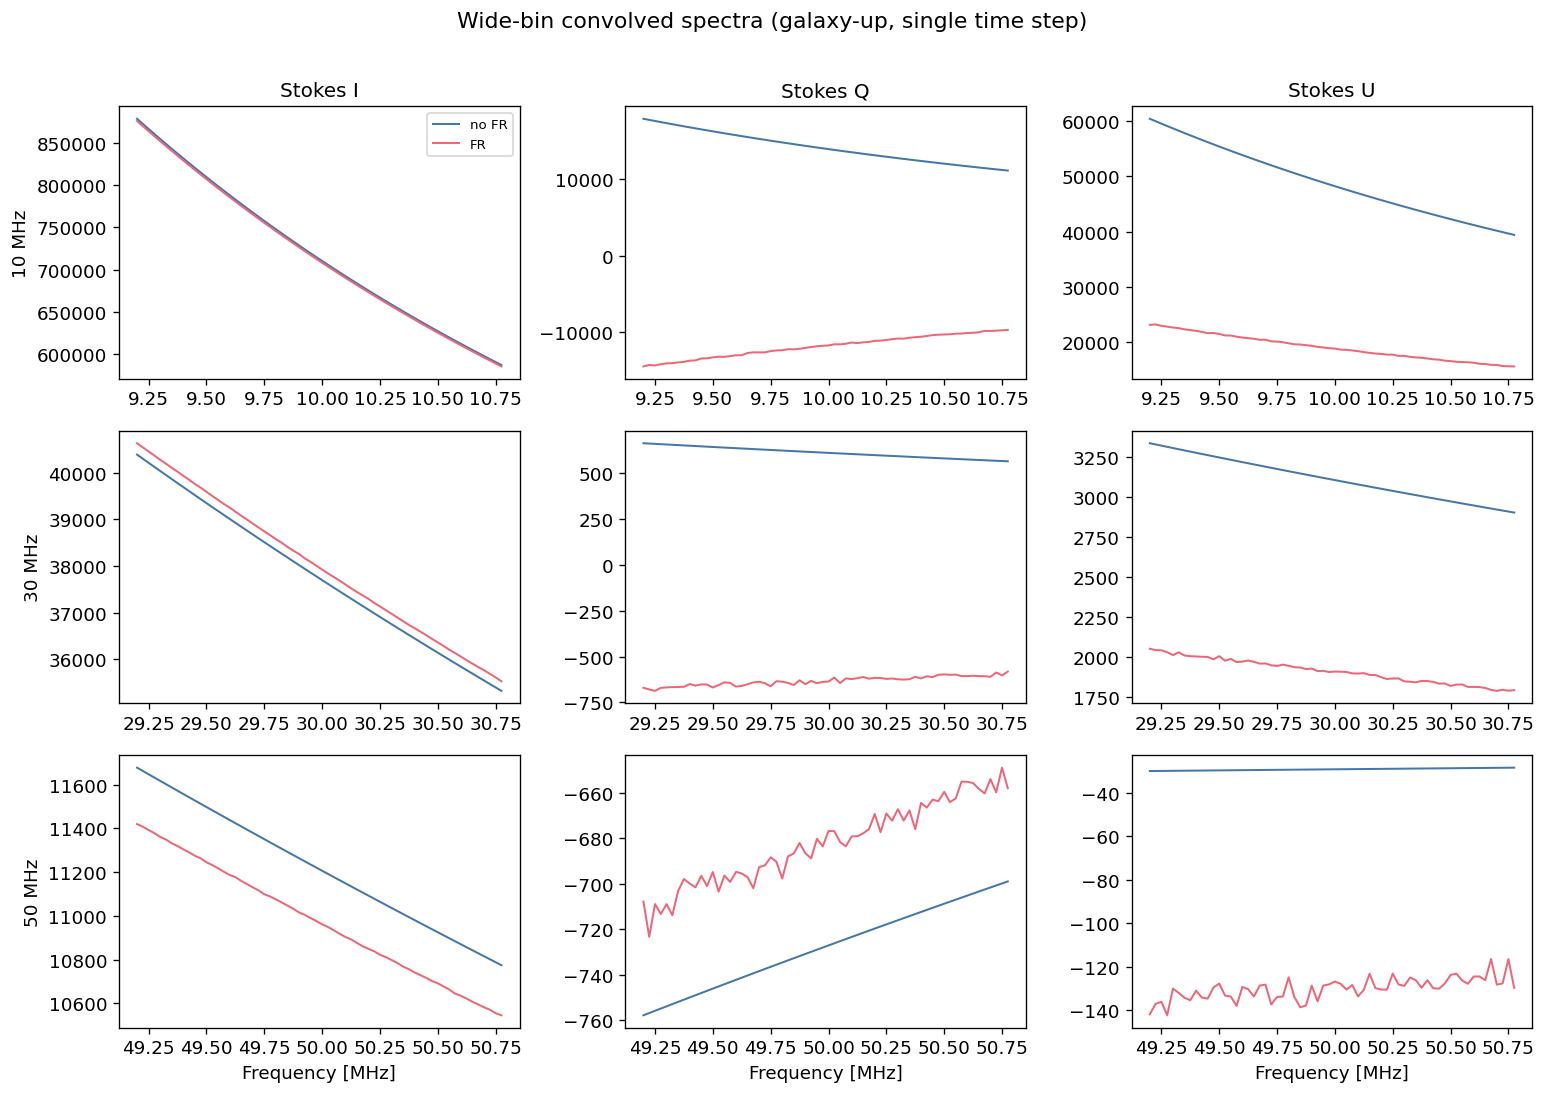

In [11]:
fig, axes = plt.subplots(3, 3, figsize=(13, 9))
stokes_wconv = [("pI", "I"), ("pQ", "Q"), ("pU", "U")]

for row, freq in enumerate([10, 30, 50]):
    d = sims[freq]
    fw = d["freqs_wide"]

    for col, (key, slbl) in enumerate(stokes_wconv):
        ax = axes[row, col]
        y_fr = d[f"{key}_FR_wconv"][0]
        y_no = d[f"{key}_noFR_wconv"][0]

        ax.plot(fw, y_no, color=C_BLUE, lw=1.2, label="no FR")
        ax.plot(fw, y_fr, color=C_RED, lw=1.2, label="FR")
        if row == 0:
            ax.set_title(f"Stokes {slbl}")
        if col == 0:
            ax.set_ylabel(f"{freq} MHz")
        if row == 2:
            ax.set_xlabel("Frequency [MHz]")
        if row == 0 and col == 0:
            ax.legend(fontsize=8)

fig.suptitle(
    "Wide-bin convolved spectra (galaxy-up, single time step)",
    y=1.01,
)
fig.tight_layout()
plt.show()